# Cálculo del Índice de Calidad de Detección (ICD) - Datos 2026

**Objetivo:** Calcular el ICD para las simulaciones 2026 y comparar con resultados previos.

**Fórmula del ICD:**

$$
\text{ICD} = \underbrace{\text{DetOK}}_{\text{Componente D}} \times \underbrace{\frac{\ln(1 + \alpha \times \%)}{\ln(1 + \alpha \times \%_{\max})}}_{\text{Componente } C_{\text{norm}}} \times \underbrace{e^{-\beta \times N_{\text{FP}}}}_{\text{Penalización } P_{\text{FP}}}
$$

**Donde:**
- **DetOK:** Éxito de detección (0, 0.5, 1)
  - `0`: Fallo completo
  - `0.5`: Detección indirecta (nodos cercanos)
  - `1`: Detección directa
- **C_norm:** Confianza normalizada (penaliza detección en severidades bajas)
  - `α = 0.1` (factor de ajuste)
  - `%_max = 45%` para abolladuras, `%_max = 90%` para corrosión
- **P_FP:** Penalización exponencial por falsos positivos
  - `β = 0.15` (factor de penalización)
  - `N_FP`: Número de falsos positivos

**Referencias:**
- Pipeline original: `outputs/resultados_antiguos/resultados_abolladuras/jupyter_notebooks/analisis_datos_abolladura.ipynb`
- Documentación: `outputs/Resultados/registro_pipeline_danos.md`

In [31]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

# Configuración de gráficas
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")
%matplotlib inline

print("✓ Librerías cargadas")

✓ Librerías cargadas


## 1. Configuración y Carga de Datos

In [32]:
# Rutas absolutas
base_path = Path.home() / 'github' / 'Proyecto-doctoral'
resultados_nuevos = base_path / 'outputs' / 'resultados_nuevos'

# Selección de tipo de daño
TIPO_DANO = 'abolladura'  # Cambiar a 'corrosion' para procesar corrosión

# Rutas según tipo de daño
if TIPO_DANO == 'abolladura':
    df_path = resultados_nuevos / 'abolladuras_2026' / 'todos_los_resultados_remapeado_final.xlsx'
    output_dir = resultados_nuevos / 'abolladuras_2026'
    porcentaje_max = 45  # [%] Severidad máxima en abolladuras
    TIPO_DANO_EN = 'Denting'  # Nombre en inglés para gráficas
elif TIPO_DANO == 'corrosion':
    df_path = resultados_nuevos / 'corrosion_2026' / 'todos_los_resultados_remapeado_final.xlsx'
    output_dir = resultados_nuevos / 'corrosion_2026'
    porcentaje_max = 90  # [%] Severidad máxima en corrosión
    TIPO_DANO_EN = 'Corrosion'  # Nombre en inglés para gráficas
else:
    raise ValueError(f"Tipo de daño '{TIPO_DANO}' no reconocido")

# Parámetros del ICD (validados en análisis previos)
ALPHA = 0.1   # Factor de ajuste para confianza
BETA = 0.15   # Factor de penalización por falsos positivos

print(f"\n{'='*70}")
print(f"CONFIGURACIÓN - {TIPO_DANO.upper()}")
print(f"{'='*70}")
print(f"Dataset: {df_path.name}")
print(f"Existe: {df_path.exists()}")
print(f"\nParámetros del ICD:")
print(f"  α (confianza): {ALPHA}")

print(f"  β (penalización): {BETA}")
print(f"  %_max: {porcentaje_max}%")


CONFIGURACIÓN - ABOLLADURA
Dataset: todos_los_resultados_remapeado_final.xlsx
Existe: True

Parámetros del ICD:
  α (confianza): 0.1
  β (penalización): 0.15
  %_max: 45%


In [ ]:
abolladura Cargar dataset remapeado
print("\n📂 Cargando dataset remapeado...")
df = pd.read_excel(df_path, engine='openpyxl')

print(f"✓ Dimensiones: {df.shape}")
print(f"✓ Columnas: {list(df.columns)}")
print(f"\n📊 Primeras 5 filas:")
display(df.head())

# Verificar presencia de columnas requeridas
required_cols = ['ID', 'Elemento', 'Porcentaje', 'DeteccionOK', 'N_FalsosPositivos']
missing_cols = [col for col in required_cols if col not in df.columns]

if missing_cols:
    raise ValueError(f"Columnas faltantes: {missing_cols}")

print(f"\n✓ Todas las columnas requeridas presentes")


📂 Cargando dataset remapeado...
✓ Dimensiones: (1080, 18)
✓ Columnas: ['ID', 'Elemento', 'Porcentaje', 'Tiempo_s', 'ObjFinal', 'DeteccionOK', 'N_FalsosPositivos', 'alpha1', 'alpha2', 'alpha3', 'alpha4', 'alpha5', 'alpha6', 'alpha7', 'alpha8', 'MAC_minimo', 'MAC_promedio', 'Hubo_cruces_modales']

📊 Primeras 5 filas:


,ID,Elemento,Porcentaje,Tiempo_s,ObjFinal,DeteccionOK,N_FalsosPositivos,alpha1,alpha2,alpha3,alpha4,alpha5,alpha6,alpha7,alpha8,MAC_minimo,MAC_promedio,Hubo_cruces_modales
0,1,1,5,138.147974,0.925560,0.5,4,0.007319,0.000038,0.000031,0.000012,0.000005,0.144129,0.000015,0.000004,0.500416,0.752289,False
1,2,1,10,222.056862,0.909825,0.5,4,0.003770,0.000043,0.000027,0.000020,0.000002,0.163834,0.000023,0.000028,0.500436,0.752465,False
2,3,1,15,305.609196,0.887863,0.5,4,0.000007,0.000003,0.000012,0.000019,0.000029,0.187741,0.000005,0.000017,0.500640,0.753898,False
3,4,1,20,388.987465,0.846761,0.5,4,0.000027,0.000002,0.000025,0.000037,0.000087,0.221312,0.000033,0.000030,0.502512,0.804982,False
4,5,1,25,453.769687,0.796903,0.5,2,0.000108,0.000016,0.000008,0.000025,0.000045,0.254924,0.000001,0.000002,0.500959,0.754893,False



✓ Todas las columnas requeridas presentes


## 2. Cálculo del ICD

In [34]:
def calcular_ICD(df, alpha, beta, porcentaje_max):
    """
    Calcula el Índice de Calidad de Detección (ICD).
    
    ICD = DetOK × [ln(1 + α×%) / ln(1 + α×%_max)] × exp(-β × N_FP)
    
    Parámetros:
    -----------
    df : DataFrame
        Dataset con columnas: Porcentaje, DeteccionOK, N_FalsosPositivos
    alpha : float
        Factor de ajuste para confianza (típicamente 0.1)
    beta : float
        Factor de penalización por falsos positivos (típicamente 0.15)
    porcentaje_max : float
        Severidad máxima del tipo de daño (%)
    
    Retorna:
    --------
    DataFrame : Dataset original con columnas adicionales:
        - C_norm: Componente de confianza normalizada
        - P_FP: Penalización por falsos positivos
        - ICD: Índice de Calidad de Detección
    """
    df_icd = df.copy()
    
    # Componente 1: Éxito de detección (D)
    # Ya está en DeteccionOK (0, 0.5, 1)
    D = df_icd['DeteccionOK']
    
    # Componente 2: Confianza normalizada (C_norm)
    # Penaliza detecciones en severidades bajas
    C_norm = np.log(1 + alpha * df_icd['Porcentaje']) / np.log(1 + alpha * porcentaje_max)
    
    # Componente 3: Penalización por falsos positivos (P_FP)
    # Decae exponencialmente con el número de FPs
    P_FP = np.exp(-beta * df_icd['N_FalsosPositivos'])
    
    # Calcular ICD
    ICD = D * C_norm * P_FP
    
    # Agregar columnas al DataFrame
    df_icd['C_norm'] = C_norm
    df_icd['P_FP'] = P_FP
    df_icd['ICD'] = ICD
    
    return df_icd


# Aplicar cálculo
print(f"\n💻 Calculando ICD...")
df_icd = calcular_ICD(df, alpha=ALPHA, beta=BETA, porcentaje_max=porcentaje_max)

print(f"✓ ICD calculado para {len(df_icd)} corridas")
print(f"\n📊 Estadísticas del ICD:")
print(df_icd['ICD'].describe())

# Mostrar ejemplos
print(f"\n📋 Ejemplos de ICD calculado:")
cols_mostrar = ['ID', 'Elemento', 'Porcentaje', 'DeteccionOK', 'N_FalsosPositivos', 'C_norm', 'P_FP', 'ICD']
display(df_icd[cols_mostrar].head(10))


💻 Calculando ICD...
✓ ICD calculado para 1080 corridas

📊 Estadísticas del ICD:
count    1080.000000
mean        0.454345
std         0.304594
min         0.000000
25%         0.179356
50%         0.462625
75%         0.734867
max         1.000000
Name: ICD, dtype: float64

📋 Ejemplos de ICD calculado:


,ID,Elemento,Porcentaje,DeteccionOK,N_FalsosPositivos,C_norm,P_FP,ICD
0,1,1,5,0.5,4,0.237845,0.548812,0.065266
1,2,1,10,0.5,4,0.406598,0.548812,0.111573
2,3,1,15,0.5,4,0.537493,0.548812,0.147491
3,4,1,20,0.5,4,0.644443,0.548812,0.176839
4,5,1,25,0.5,2,0.734867,0.740818,0.272201
5,6,1,30,0.5,2,0.813196,0.740818,0.301215
6,7,1,35,0.5,2,0.882287,0.740818,0.326807
7,8,1,40,0.5,4,0.944091,0.548812,0.259064
8,9,1,45,0.5,3,1.000000,0.637628,0.318814
9,10,2,5,1.0,0,0.237845,1.000000,0.237845


## 3. Análisis por Severidad


📊 ICD promedio por severidad:


,Porcentaje,ICD_mean,ICD_std,ICD_min,ICD_max,n_corridas
0,5,0.144077,0.088824,0.0,0.237845,120
1,10,0.263959,0.142798,0.0,0.406598,120
2,15,0.349807,0.187651,0.0,0.537493,120
3,20,0.426393,0.229522,0.0,0.644443,120
4,25,0.490736,0.255320,0.0,0.734867,120
5,30,0.549097,0.272967,0.0,0.813196,120
6,35,0.584937,0.312522,0.0,0.882287,120
7,40,0.623701,0.336617,0.0,0.944091,120
8,45,0.656398,0.362307,0.0,1.000000,120


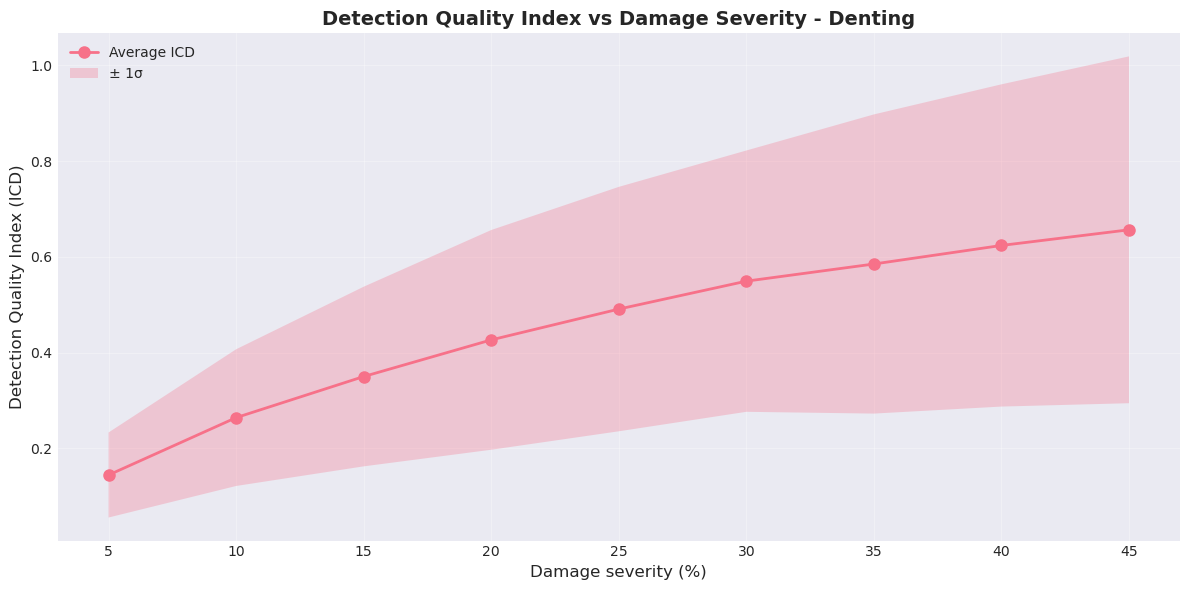


✓ Gráfica guardada: ICD_vs_severity_abolladura.png


In [35]:
# Agrupar por severidad
icd_por_severidad = df_icd.groupby('Porcentaje')['ICD'].agg(['mean', 'std', 'min', 'max', 'count']).reset_index()
icd_por_severidad.columns = ['Porcentaje', 'ICD_mean', 'ICD_std', 'ICD_min', 'ICD_max', 'n_corridas']

print(f"\n📊 ICD promedio por severidad:")
display(icd_por_severidad)

# Gráfica: ICD vs Severidad
fig, ax = plt.subplots(figsize=(12, 6))

ax.plot(icd_por_severidad['Porcentaje'], icd_por_severidad['ICD_mean'], 
        marker='o', linewidth=2, markersize=8, label='Average DQI')
ax.fill_between(icd_por_severidad['Porcentaje'], 
                icd_por_severidad['ICD_mean'] - icd_por_severidad['ICD_std'],
                icd_por_severidad['ICD_mean'] + icd_por_severidad['ICD_std'],
                alpha=0.3, label='± 1σ')

ax.set_xlabel('Damage severity (%)', fontsize=12)
ax.set_ylabel('Detection Quality Index (DQI)', fontsize=12)
ax.set_title(f'Detection Quality Index vs Damage Severity - {TIPO_DANO_EN}', fontsize=14, fontweight='bold')
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(output_dir / f'ICD_vs_severity_{TIPO_DANO}.png', dpi=300, bbox_inches='tight')
plt.show()

print(f"\n✓ Gráfica guardada: ICD_vs_severity_{TIPO_DANO}.png")

## 4. Análisis por Tipo de Elemento (si aplica)


⚠️  Columna 'Tipo_elemento_a_buscar' no encontrada. Creándola desde archivos auxiliares...
✓ Columna creada exitosamente

📊 Distribución de tipos:
Tipo_elemento_a_buscar
Brace           756
Inclined_leg    180
Beam            144
Name: count, dtype: int64

📊 ICD promedio por tipo de elemento:


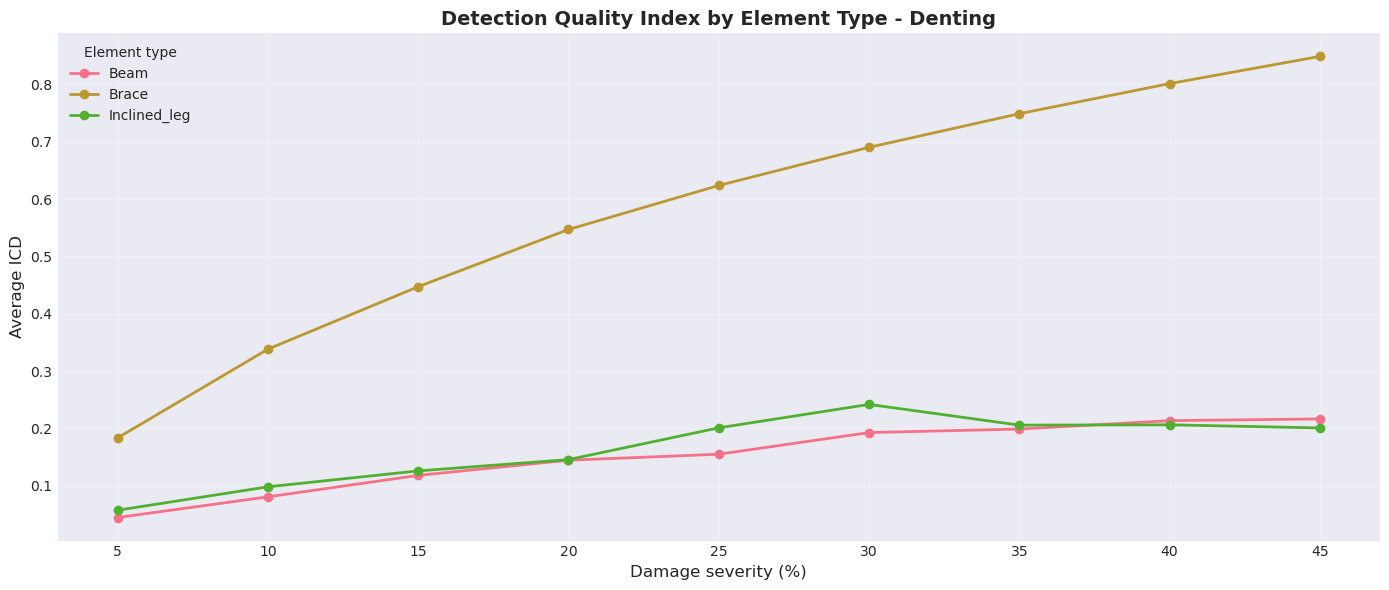


✓ Gráfica guardada: ICD_by_element_type_abolladura.png


In [36]:
# Verificar si existe columna de tipo de elemento, si no, crearla
if 'Tipo_elemento_a_buscar' not in df_icd.columns:
    print("\n⚠️  Columna 'Tipo_elemento_a_buscar' no encontrada. Creándola desde archivos auxiliares...")
    
    # Cargar mapeos de elementos
    nodos_beams = pd.read_csv(resultados_nuevos / 'nodos_beams.csv')
    nodos_legs = pd.read_csv(resultados_nuevos / 'nodos_inclined_legs.csv')
    
    # Obtener listas de elementos
    beams = nodos_beams['beam'].unique()
    legs = nodos_legs['inclined_leg'].unique()
    
    # Crear columna de tipo
    def clasificar_elemento(elem):
        if elem in beams:
            return 'Beam'
        elif elem in legs:
            return 'Inclined_leg'
        else:
            return 'Brace'  # Elementos 1-92 son braces (x_bracing)
    
    df_icd['Tipo_elemento_a_buscar'] = df_icd['Elemento'].apply(clasificar_elemento)
    
    print(f"✓ Columna creada exitosamente")
    print(f"\n📊 Distribución de tipos:")
    print(df_icd['Tipo_elemento_a_buscar'].value_counts())

# Análisis por tipo de elemento
icd_por_tipo = df_icd.groupby(['Tipo_elemento_a_buscar', 'Porcentaje'])['ICD'].mean().reset_index()

print(f"\n📊 ICD promedio por tipo de elemento:")

fig, ax = plt.subplots(figsize=(14, 6))

for tipo in icd_por_tipo['Tipo_elemento_a_buscar'].unique():
    data = icd_por_tipo[icd_por_tipo['Tipo_elemento_a_buscar'] == tipo]
    ax.plot(data['Porcentaje'], data['ICD'], marker='o', linewidth=2, label=tipo)

ax.set_xlabel('Damage severity (%)', fontsize=12)
ax.set_ylabel('Average DQI', fontsize=12)
ax.set_title(f'Detection Quality Index by Element Type - {TIPO_DANO_EN}', fontsize=14, fontweight='bold')
ax.legend(fontsize=10, title='Element type')
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(output_dir / f'ICD_by_element_type_{TIPO_DANO}.png', dpi=300, bbox_inches='tight')
plt.show()

print(f"\n✓ Gráfica guardada: ICD_by_element_type_{TIPO_DANO}.png")

## 5. Distribuciones de Componentes del ICD

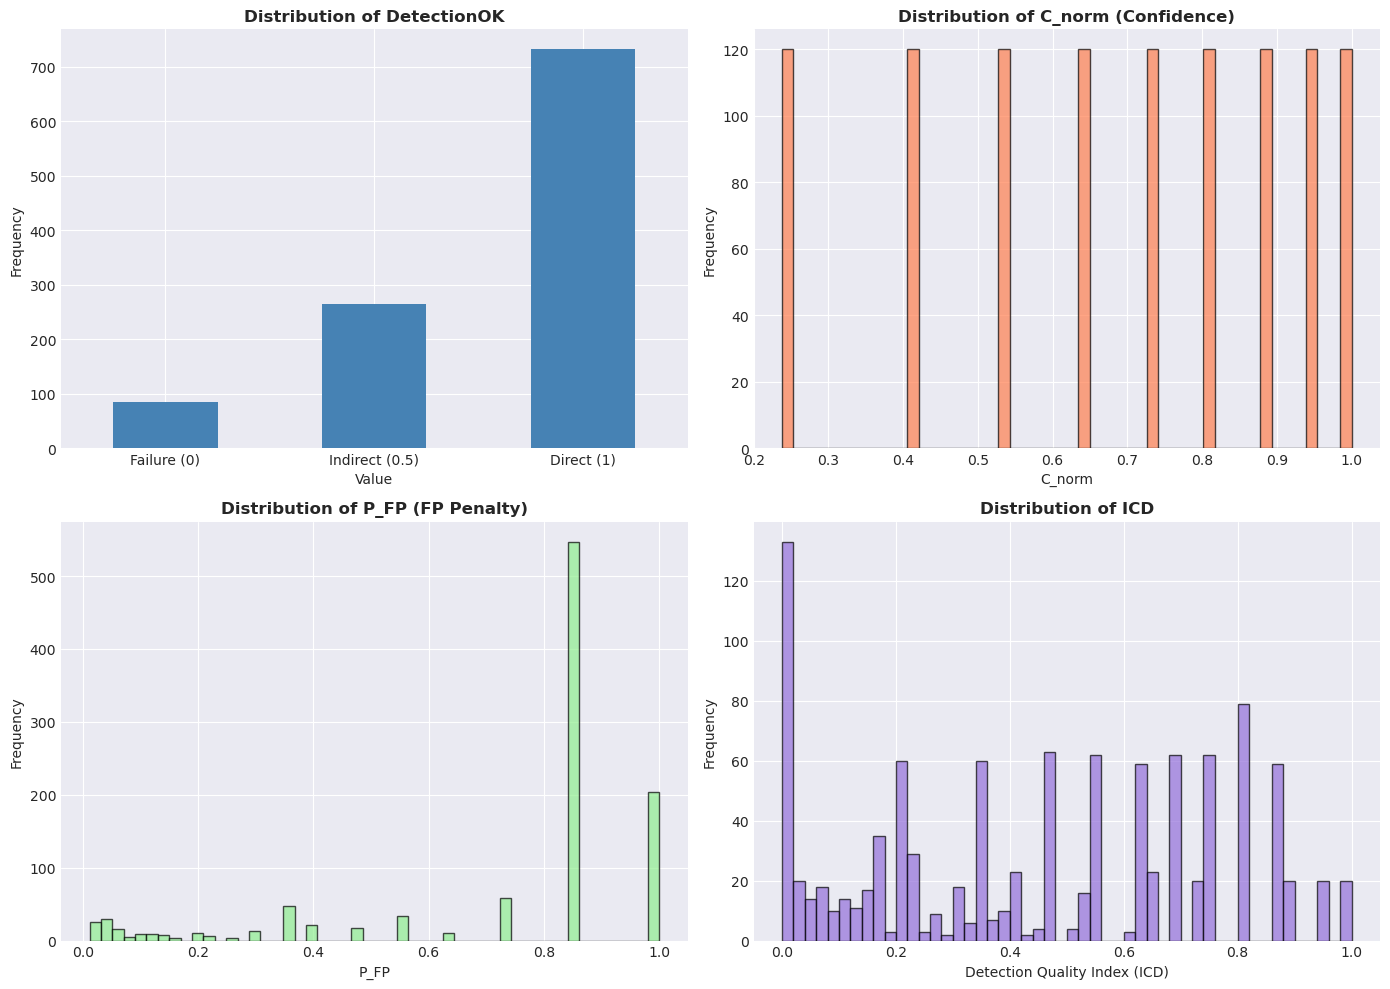


✓ Gráfica guardada: ICD_components_distributions_abolladura.png


In [37]:
# Gráfica de distribuciones
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# DeteccionOK
df_icd['DeteccionOK'].value_counts().sort_index().plot(kind='bar', ax=axes[0,0], color='steelblue')
axes[0,0].set_title('Distribution of DetectionOK', fontweight='bold')
axes[0,0].set_xlabel('Value')
axes[0,0].set_ylabel('Frequency')
axes[0,0].set_xticklabels(['Failure (0)', 'Indirect (0.5)', 'Direct (1)'], rotation=0)

# C_norm (Confianza)
axes[0,1].hist(df_icd['C_norm'], bins=50, color='coral', edgecolor='black', alpha=0.7)
axes[0,1].set_title('Distribution of C_norm (Confidence)', fontweight='bold')
axes[0,1].set_xlabel('C_norm')
axes[0,1].set_ylabel('Frequency')

# P_FP (Penalización)
axes[1,0].hist(df_icd['P_FP'], bins=50, color='lightgreen', edgecolor='black', alpha=0.7)
axes[1,0].set_title('Distribution of P_FP (FP Penalty)', fontweight='bold')
axes[1,0].set_xlabel('P_FP')
axes[1,0].set_ylabel('Frequency')

# ICD
axes[1,1].hist(df_icd['ICD'], bins=50, color='mediumpurple', edgecolor='black', alpha=0.7)
axes[1,1].set_title('Distribution of DQI', fontweight='bold')
axes[1,1].set_xlabel('Detection Quality Index (DQI)')
axes[1,1].set_ylabel('Frequency')

plt.tight_layout()
plt.savefig(output_dir / f'ICD_components_distributions_{TIPO_DANO}.png', dpi=300, bbox_inches='tight')
plt.show()

print(f"\n✓ Gráfica guardada: ICD_components_distributions_{TIPO_DANO}.png")

## 6. Análisis Binario vs ICD Continuo

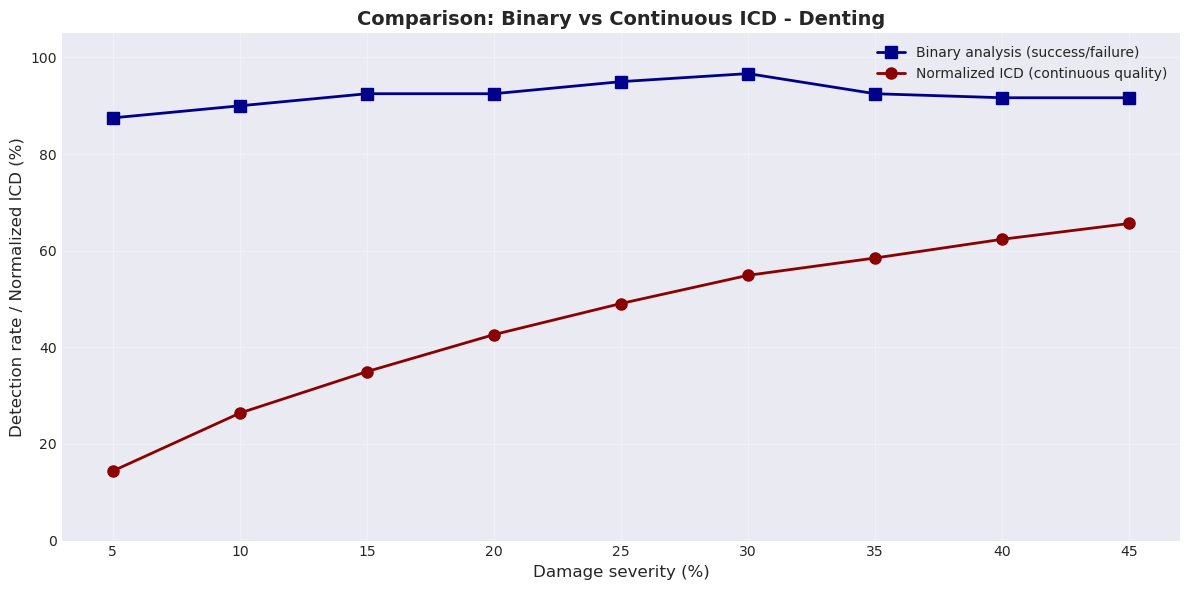


✓ Gráfica guardada: binary_vs_ICD_comparison_abolladura.png

📊 Comparación numérica:


,Severidad (%),Tasa Binaria (%),ICD Normalizado (%),Diferencia
0,5,87.5,14.4,73.1
1,10,90.0,26.4,63.6
2,15,92.5,35.0,57.5
3,20,92.5,42.6,49.9
4,25,95.0,49.1,45.9
5,30,96.7,54.9,41.8
6,35,92.5,58.5,34.0
7,40,91.7,62.4,29.3
8,45,91.7,65.6,26.0


In [38]:
# Crear análisis binario (DeteccionOK > 0 cuenta como éxito)
df_icd['DeteccionOK_binario'] = (df_icd['DeteccionOK'] > 0).astype(int)

# Tasas de detección por severidad
tasa_binaria = df_icd.groupby('Porcentaje')['DeteccionOK_binario'].mean() * 100
icd_normalizado = (df_icd.groupby('Porcentaje')['ICD'].mean() / df_icd['ICD'].max()) * 100

# Comparación
fig, ax = plt.subplots(figsize=(12, 6))

severidades = tasa_binaria.index
ax.plot(severidades, tasa_binaria.values, marker='s', linewidth=2, markersize=8, 
        label='Binary analysis (success/failure)', color='darkblue')
ax.plot(severidades, icd_normalizado.values, marker='o', linewidth=2, markersize=8, 
        label='Normalized DQI (continuous quality)', color='darkred')

ax.set_xlabel('Damage severity (%)', fontsize=12)
ax.set_ylabel('Detection rate / Normalized DQI (%)', fontsize=12)
ax.set_title(f'Comparison: Binary vs Continuous DQI - {TIPO_DANO_EN}', 
             fontsize=14, fontweight='bold')
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)
ax.set_ylim([0, 105])

plt.tight_layout()
plt.savefig(output_dir / f'binary_vs_ICD_comparison_{TIPO_DANO}.png', dpi=300, bbox_inches='tight')
plt.show()

print(f"\n✓ Gráfica guardada: binary_vs_ICD_comparison_{TIPO_DANO}.png")

# Tabla comparativa
print(f"\n📊 Comparación numérica:")
comparacion = pd.DataFrame({
    'Severidad (%)': severidades,
    'Tasa Binaria (%)': tasa_binaria.values.round(1),
    'ICD Normalizado (%)': icd_normalizado.values.round(1),
    'Diferencia': (tasa_binaria.values - icd_normalizado.values).round(1)
})
display(comparacion)

## 7. Guardar Dataset con ICD

In [39]:
# Guardar dataset completo con ICD
output_file = output_dir / f'todos_los_resultados_con_ICD_{TIPO_DANO}.xlsx'
df_icd.to_excel(output_file, index=False, engine='openpyxl')

print(f"\n{'='*70}")
print("RESUMEN FINAL")
print(f"{'='*70}")
print(f"\n✓ Dataset con ICD guardado: {output_file.name}")
print(f"\n📊 Estadísticas generales:")
print(f"  Total de corridas: {len(df_icd)}")
print(f"  ICD promedio: {df_icd['ICD'].mean():.3f} ± {df_icd['ICD'].std():.3f}")
print(f"  ICD mínimo: {df_icd['ICD'].min():.3f}")
print(f"  ICD máximo: {df_icd['ICD'].max():.3f}")
print(f"\n  Detecciones directas: {(df_icd['DeteccionOK'] == 1).sum()} ({100*(df_icd['DeteccionOK'] == 1).sum()/len(df_icd):.1f}%)")
print(f"  Detecciones indirectas: {(df_icd['DeteccionOK'] == 0.5).sum()} ({100*(df_icd['DeteccionOK'] == 0.5).sum()/len(df_icd):.1f}%)")
print(f"  Fallos completos: {(df_icd['DeteccionOK'] == 0).sum()} ({100*(df_icd['DeteccionOK'] == 0).sum()/len(df_icd):.1f}%)")
print(f"\n📁 Archivos generados:")
for file in output_dir.glob('*.png'):
    print(f"  - {file.name}")
print(f"\n{'='*70}")
print("✅ Cálculo de ICD completado exitosamente")
print(f"{'='*70}")


RESUMEN FINAL

✓ Dataset con ICD guardado: todos_los_resultados_con_ICD_abolladura.xlsx

📊 Estadísticas generales:
  Total de corridas: 1080
  ICD promedio: 0.454 ± 0.305
  ICD mínimo: 0.000
  ICD máximo: 1.000

  Detecciones directas: 732 (67.8%)
  Detecciones indirectas: 264 (24.4%)
  Fallos completos: 84 (7.8%)

📁 Archivos generados:
  - distribuciones_componentes_ICD_abolladura.png
  - ICD_components_distributions_abolladura.png
  - binary_vs_ICD_comparison_abolladura.png
  - ICD_por_tipo_elemento_abolladura.png
  - ICD_by_element_type_abolladura.png
  - comparacion_binario_vs_ICD_abolladura.png
  - ICD_vs_severity_abolladura.png
  - ICD_vs_severidad_abolladura.png

✅ Cálculo de ICD completado exitosamente


## 📝 Notas

**Interpretación del ICD:**
- **ICD = 0:** Fallo completo (no se detectó el elemento ni nodos cercanos)
- **0 < ICD < 0.5:** Detección de baja calidad (puede ser indirecta o con muchos FPs)
- **0.5 ≤ ICD < 0.8:** Detección de calidad media
- **ICD ≥ 0.8:** Detección de alta calidad (directa, severidad alta, pocos FPs)

**Diferencias clave vs análisis binario:**
- El análisis binario trata todas las detecciones (directas e indirectas) por igual
- El ICD pondera:
  - Detecciones indirectas (0.5) tienen 50% del peso de las directas (1.0)
  - Severidades bajas reducen el ICD
  - Falsos positivos penalizan exponencialmente

**Próximos pasos:**
1. Repetir para corrosión (cambiar `TIPO_DANO = 'corrosion'` en celda 2)
2. Comparar ICD 2026 vs resultados previos
3. Análisis estadístico de vectores alpha (α₁-α₈)
4. Correlación entre ICD y alphas